<h1><b>IPL Cricket Data Analysis & Performance Insights</b><br>
Exploratory Data Analysis of IPL Match & Ball-by-Ball Data (2008–2022)

## Project Overview

This project analyzes IPL match and ball-by-ball data from 2008 to 2022 to uncover insights into player performance, batting, bowling, team performance, and match trends.

The analysis focuses on identifying top-performing players, season-wise performance, Purple Cap holders, death-over bowling performance, and other important patterns in IPL data.

*This notebook was cleaned up and restructured: duplicate/dead cells were removed, sections were consolidated, variable names were made descriptive, and a chart was added to every section to make the insights visible rather than just tabular.*

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook / Google Colab

## Objectives

- Analyze IPL batting and bowling performance.
- Identify top-performing players across seasons.
- Determine the Purple Cap holder for each season.
- Analyze bowling performance during death overs.
- Explore season-wise and team-wise IPL trends.
- Derive meaningful insights from ball-by-ball data.

## Setup & Data Loading

All three source files are loaded once, up front, and reused throughout the notebook (the original version re-read the same CSVs multiple times in different sections).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

In [4]:
# NOTE: paths assume Colab with the files uploaded to /content/.
# Update these paths if you're running locally or the filenames differ.
ipl_ball_by_ball = pd.read_csv('/content/IPL_Ball_by_Ball_2008_2022.csv')
ipl_matches = pd.read_csv('/content/IPL_Matches_2008_2022.csv')
ipl_deliveries = pd.read_csv('/content/ipl_deliveries.csv')

# Ball-by-ball deliveries joined with match metadata (Season, teams, etc.) — reused in several sections below
ipl_df = ipl_deliveries.merge(ipl_matches, on='ID')

print('ipl_ball_by_ball:', ipl_ball_by_ball.shape)
print('ipl_matches:', ipl_matches.shape)
print('ipl_deliveries:', ipl_deliveries.shape)
print('ipl_df (deliveries + match info):', ipl_df.shape)

ipl_ball_by_ball: (225954, 17)
ipl_matches: (950, 20)
ipl_deliveries: (225954, 19)
ipl_df (deliveries + match info): (225954, 38)


## 1. Purple Cap Holder for Each Season

Identify the Purple Cap holder for each IPL season based on the highest number of wickets, with economy rate used as the tie-breaker.

In [5]:
# Wickets taken per bowler per season (excludes run-outs, which aren't credited to the bowler)
dismissal_kinds = ['bowled', 'caught', 'caught and bowled', 'lbw', 'stumped', 'hit wicket']

season_wickets = (
    ipl_ball_by_ball[ipl_ball_by_ball['kind'].isin(dismissal_kinds)]
    .merge(ipl_matches[['ID', 'Season']], on='ID')
    .groupby(['Season', 'bowler'])
    .size()
    .reset_index(name='wickets')
)
season_wickets.head()

,Season,bowler,wickets
0,2007/08,A Kumble,7
1,2007/08,A Mishra,11
2,2007/08,A Nehra,12
3,2007/08,A Nel,1
4,2007/08,AA Noffke,1


In [6]:
# Legal balls bowled per bowler per season (wides and no-balls don't count as balls faced)
season_balls = (
    ipl_ball_by_ball[~ipl_ball_by_ball['extra_type'].isin(['wides', 'noballs'])]
    .merge(ipl_matches[['ID', 'Season']], on='ID')
    .groupby(['Season', 'bowler'])
    .size()
    .reset_index(name='balls')
)

# Runs conceded per bowler per season (byes/leg-byes aren't charged to the bowler)
season_runs = (
    ipl_ball_by_ball[~ipl_ball_by_ball['extra_type'].isin(['legbyes', 'byes'])]
    .merge(ipl_matches[['ID', 'Season']], on='ID')
    .groupby(['Season', 'bowler'])['total_run']
    .sum()
    .reset_index(name='runs')
)

season_economy = season_balls.merge(season_runs, on=['Season', 'bowler'])
season_economy['economy'] = season_economy['runs'] * 6 / season_economy['balls']
season_economy.head()

,Season,bowler,balls,runs,economy
0,2007/08,A Kumble,230,304,7.930435
1,2007/08,A Mishra,119,138,6.957983
2,2007/08,A Nehra,269,348,7.762082
3,2007/08,A Nel,18,31,10.333333
4,2007/08,A Symonds,41,101,14.780488


In [7]:
purple_cap_df = (
    season_wickets
    .merge(season_economy, on=['Season', 'bowler'])
    .sort_values(['Season', 'wickets', 'economy'], ascending=[True, False, True])
    .groupby('Season')
    .head(1)
    [['Season', 'bowler', 'wickets', 'economy']]
    .reset_index(drop=True)
)
purple_cap_df

,Season,bowler,wickets,economy
0,2007/08,Sohail Tanvir,22,6.461538
1,2009,RP Singh,23,6.988827
2,2009/10,PP Ojha,21,7.291785
3,2011,SL Malinga,28,5.952381
4,2012,M Morkel,25,7.190476
5,2013,DJ Bravo,32,7.952000
6,2014,MM Sharma,23,8.396285
7,2015,DJ Bravo,26,8.140127
8,2016,B Kumar,23,7.424242
9,2017,B Kumar,26,7.050955


In [8]:
latest = purple_cap_df.iloc[-1]
print(f"Most recent Purple Cap ({latest['Season']}): {latest['bowler']} — {latest['wickets']} wickets at an economy of {latest['economy']:.2f}")

Most recent Purple Cap (2022): YS Chahal — 27 wickets at an economy of 7.75


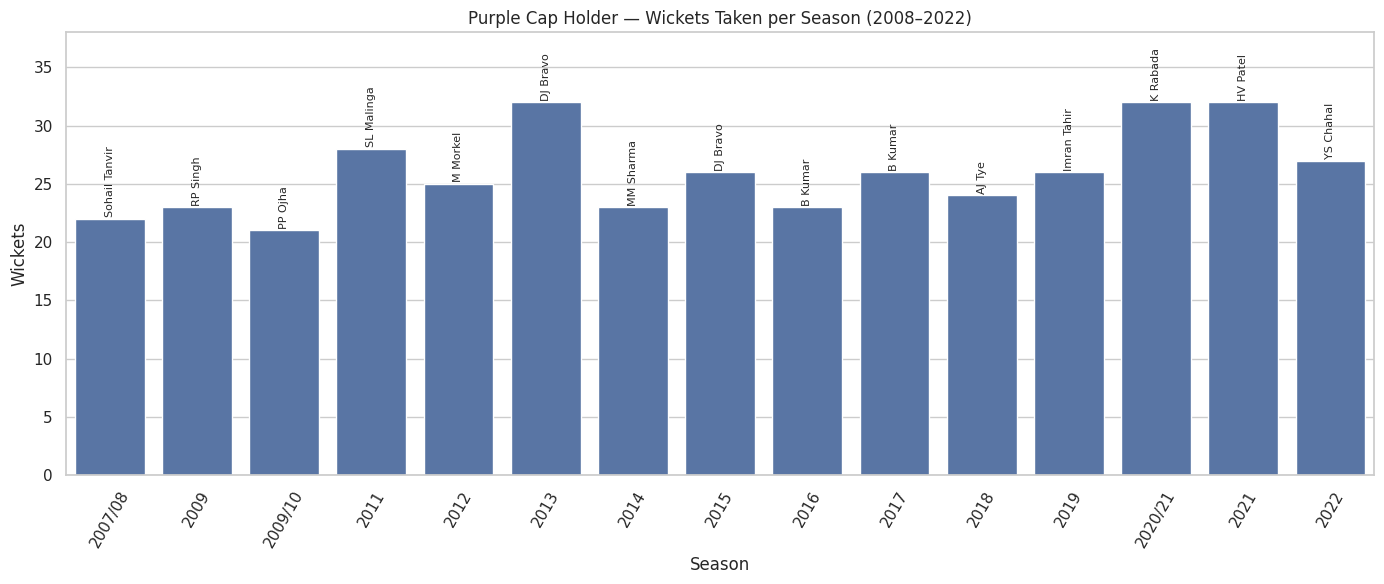

In [9]:
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=purple_cap_df, x='Season', y='wickets', color='#4C72B0')

for i, row in enumerate(purple_cap_df.itertuples()):
    ax.text(i, row.wickets + 0.3, row.bowler, ha='center', rotation=90, fontsize=8)

plt.title('Purple Cap Holder — Wickets Taken per Season (2008–2022)')
plt.ylabel('Wickets')
plt.xlabel('Season')
plt.xticks(rotation=60)
plt.ylim(0, purple_cap_df['wickets'].max() + 6)
plt.tight_layout()
plt.show()

## 2. Best Bowler in Death Overs (Overs 16–20)

Identify the best death-over bowler per season based on wickets taken, with economy rate as the tie-breaker.

In [10]:
death_over_mask = ipl_ball_by_ball['overs'].between(16, 20)

death_wickets = (
    ipl_ball_by_ball[death_over_mask & ipl_ball_by_ball['kind'].isin(dismissal_kinds)]
    .merge(ipl_matches[['ID', 'Season']], on='ID')
    .groupby(['Season', 'bowler'])
    .size()
    .reset_index(name='wickets')
)

death_balls = (
    ipl_ball_by_ball[death_over_mask & ~ipl_ball_by_ball['extra_type'].isin(['wides', 'noballs'])]
    .merge(ipl_matches[['ID', 'Season']], on='ID')
    .groupby(['Season', 'bowler'])
    .size()
    .reset_index(name='balls')
)

death_runs = (
    ipl_ball_by_ball[death_over_mask & ~ipl_ball_by_ball['extra_type'].isin(['byes', 'legbyes'])]
    .merge(ipl_matches[['ID', 'Season']], on='ID')
    .groupby(['Season', 'bowler'])['total_run']
    .sum()
    .reset_index(name='runs_conceded')
)

death_over_stats = death_balls.merge(death_runs, on=['Season', 'bowler']).merge(death_wickets, on=['Season', 'bowler'])
death_over_stats['economy'] = death_over_stats['runs_conceded'] * 6 / death_over_stats['balls']
death_over_stats.head()

,Season,bowler,balls,runs_conceded,wickets,economy
0,2007/08,A Mishra,6,2,3,2.000000
1,2007/08,A Nehra,47,83,2,10.595745
2,2007/08,AA Noffke,6,7,1,7.000000
3,2007/08,AB Agarkar,12,11,2,5.500000
4,2007/08,B Akhil,8,16,1,12.000000


In [11]:
death_over_leader = (
    death_over_stats
    .sort_values(['Season', 'wickets', 'economy'], ascending=[True, False, True])
    .groupby('Season')
    .head(1)
    [['Season', 'bowler', 'wickets', 'economy']]
    .reset_index(drop=True)
)
death_over_leader

,Season,bowler,wickets,economy
0,2007/08,Sohail Tanvir,16,6.562500
1,2009,RP Singh,12,7.423729
2,2009/10,RJ Harris,8,11.531250
3,2011,SL Malinga,12,6.842105
4,2012,SP Narine,18,7.035971
5,2013,DJ Bravo,20,8.150943
6,2014,MM Sharma,14,10.487395
7,2015,DJ Bravo,21,8.576471
8,2016,B Kumar,11,9.761905
9,2017,B Kumar,16,8.194030


In [12]:
latest = death_over_leader.iloc[-1]
print(f"Best death-over bowler in {latest['Season']}: {latest['bowler']} — {latest['wickets']} wickets at an economy of {latest['economy']:.2f}")

Best death-over bowler in 2022: DJ Bravo — 11 wickets at an economy of 9.16


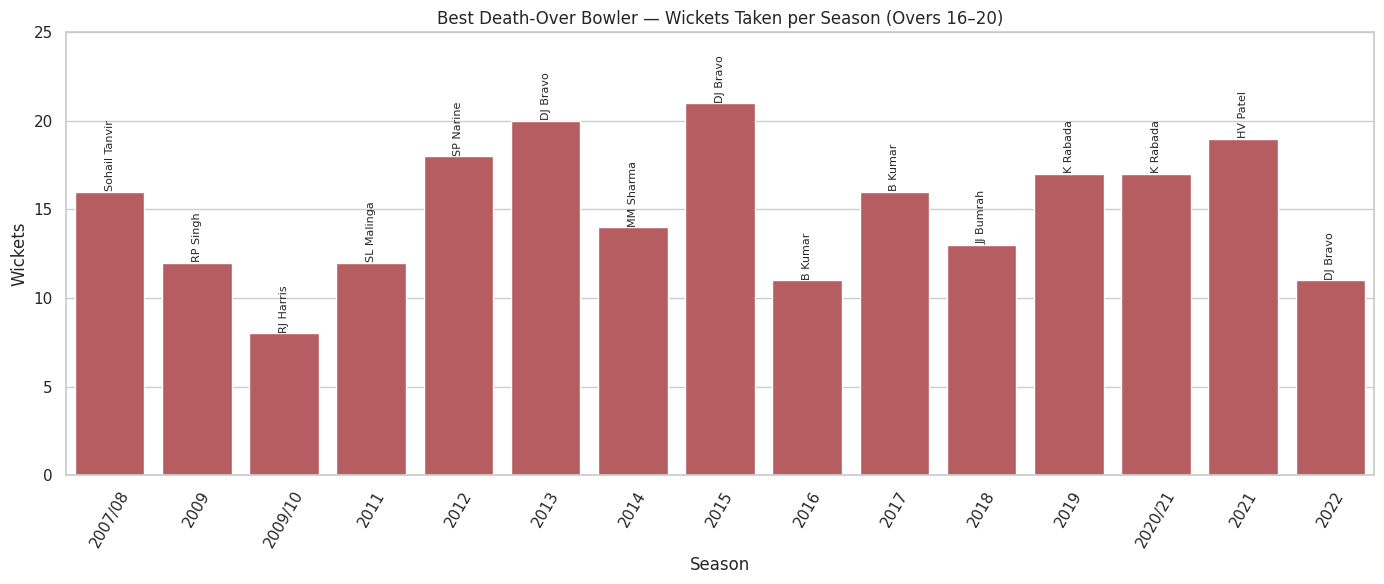

In [13]:
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=death_over_leader, x='Season', y='wickets', color='#C44E52')

for i, row in enumerate(death_over_leader.itertuples()):
    ax.text(i, row.wickets + 0.15, row.bowler, ha='center', rotation=90, fontsize=8)

plt.title('Best Death-Over Bowler — Wickets Taken per Season (Overs 16–20)')
plt.ylabel('Wickets')
plt.xlabel('Season')
plt.xticks(rotation=60)
plt.ylim(0, death_over_leader['wickets'].max() + 4)
plt.tight_layout()
plt.show()

## 3. Season-wise Batting Record for a Player

A function that takes a batter's name and returns a season-wise record with columns `['Innings', 'TotalRuns', 'Avg', 'HighestScore', 'StrikeRate']`, indexed by `Season`.

- **Avg** = TotalRuns / times dismissed (if never dismissed in a season, Avg = TotalRuns for that season).
- **StrikeRate** = (TotalRuns / balls faced) × 100 — wides don't count as a ball faced, no-balls do.

*(This consolidates three earlier draft versions of this function into one clean, correct version.)*

In [14]:
def batter_score(name):
    """Season-wise batting record for a given batter."""
    filtered_df = ipl_df[ipl_df['batter'] == name]

    innings = filtered_df.groupby('Season')['ID'].nunique()
    total_runs = filtered_df.groupby('Season')['batsman_run'].sum()

    highest_score = (
        filtered_df.groupby(['Season', 'ID'])['batsman_run']
        .sum()
        .groupby('Season')
        .max()
    )

    dismissals = (
        ipl_df[ipl_df['player_out'] == name]
        .groupby('Season')['player_out']
        .count()
    )

    balls_faced = (
        filtered_df[filtered_df['extra_type'] != 'wides']
        .groupby('Season')['ballnumber']
        .count()
    )

    stats = pd.DataFrame({
        'Innings': innings,
        'TotalRuns': total_runs,
        'HighestScore': highest_score,
        'Dismissals': dismissals,
        'BallsFaced': balls_faced,
    }).fillna(0)

    stats['Avg'] = stats.apply(
        lambda row: row['TotalRuns'] if row['Dismissals'] == 0 else row['TotalRuns'] / row['Dismissals'],
        axis=1,
    )
    stats['StrikeRate'] = (stats['TotalRuns'] / stats['BallsFaced']) * 100

    return stats[['Innings', 'TotalRuns', 'Avg', 'HighestScore', 'StrikeRate']]

In [15]:
player_name = 'V Kohli'  # change this to look up any batter in the dataset
batter_stats = batter_score(player_name)
batter_stats

,Innings,TotalRuns,Avg,HighestScore,StrikeRate
Season,,,,,
2007/08,12,165,15.000000,38,105.095541
2009,13,246,22.363636,50,112.328767
2009/10,13,307,27.909091,58,144.811321
2011,16,557,46.416667,71,121.086957
2012,15,364,28.000000,73,111.656442
2013,16,639,45.642857,99,139.215686
2014,14,359,27.615385,73,122.108844
2015,16,505,45.909091,82,130.829016
2016,16,973,81.083333,113,152.031250


/tmp/ipykernel_2900/2307950933.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(seasons, rotation=60)


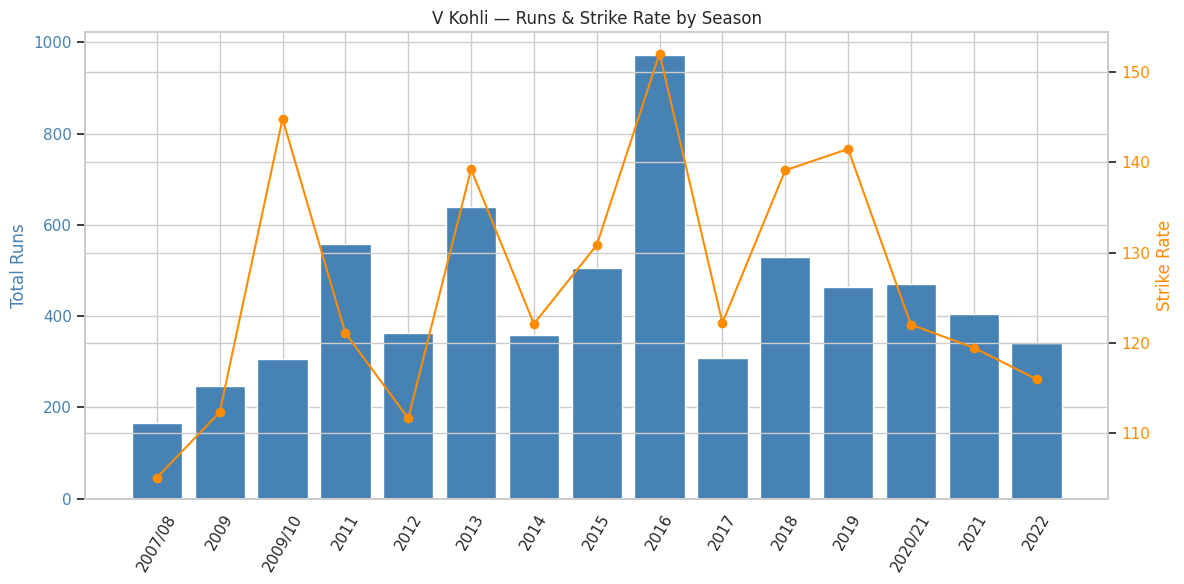

In [16]:
fig, ax1 = plt.subplots(figsize=(12, 6))

seasons = batter_stats.index.astype(str)
ax1.bar(seasons, batter_stats['TotalRuns'], color='steelblue', label='Total Runs')
ax1.set_ylabel('Total Runs', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(seasons, batter_stats['StrikeRate'], color='darkorange', marker='o', label='Strike Rate')
ax2.set_ylabel('Strike Rate', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title(f'{player_name} — Runs & Strike Rate by Season')
ax1.set_xticklabels(seasons, rotation=60)
fig.tight_layout()
plt.show()

## 4. Player-of-the-Match Performance Summary

For each match, build a record showing the Player-of-the-Match award winner along with their batting figure (`runs/balls`) and bowling figure (`wickets/runs-conceded`) *in that match*. A player who didn't bat or bowl in the match gets `NaN` for that figure.

*(The original version of this section built this up across ~25 exploratory cells and had a bug — a column-name mismatch (`batting_figure` vs `BattingFigure`) that raised a `KeyError` when run. It's rebuilt here as a single clean pipeline.)*

In [17]:
match_pom = ipl_matches[['ID', 'Player_of_Match']].drop_duplicates().set_index('ID')

# --- Batting figure: runs/balls faced by the Player of the Match, in that match ---
pom_batting = ipl_df[ipl_df['batter'] == ipl_df['Player_of_Match']]

pom_runs = pom_batting.groupby('ID')['batsman_run'].sum()
pom_balls = pom_batting[pom_batting['extra_type'] != 'wides'].groupby('ID').size()

batting_figure = (
    pom_runs.astype(int).astype(str) + '/' + pom_balls.reindex(pom_runs.index).fillna(0).astype(int).astype(str)
)

# --- Bowling figure: wickets/runs-conceded by the Player of the Match, in that match ---
pom_bowling = ipl_df[ipl_df['bowler'] == ipl_df['Player_of_Match']]

pom_wickets = pom_bowling[pom_bowling['isWicketDelivery'] == 1].groupby('ID').size()
pom_runs_conceded = (
    pom_bowling[~pom_bowling['extra_type'].isin(['byes', 'legbyes'])]
    .groupby('ID')['total_run']
    .sum()
)

bowling_figure = (
    pom_wickets.reindex(pom_runs_conceded.index).fillna(0).astype(int).astype(str)
    + '/' + pom_runs_conceded.astype(int).astype(str)
)

final_df = match_pom.copy()
final_df['BattingFigure'] = batting_figure
final_df['BowlingFigure'] = bowling_figure
final_df = final_df.rename(columns={'Player_of_Match': 'PlayerOfTheMatch'})
final_df.head(10)

,PlayerOfTheMatch,BattingFigure,BowlingFigure
ID,,,
1312200,HH Pandya,34/30,3/17
1312199,JC Buttler,106/60,NaN
1312198,RM Patidar,112/54,NaN
1312197,DA Miller,68/38,NaN
1304116,Harpreet Brar,NaN,3/26
1304115,JJ Bumrah,NaN,3/25
1304114,R Ashwin,40/23,1/28
1304113,V Kohli,73/54,NaN
1304112,Q de Kock,140/70,NaN


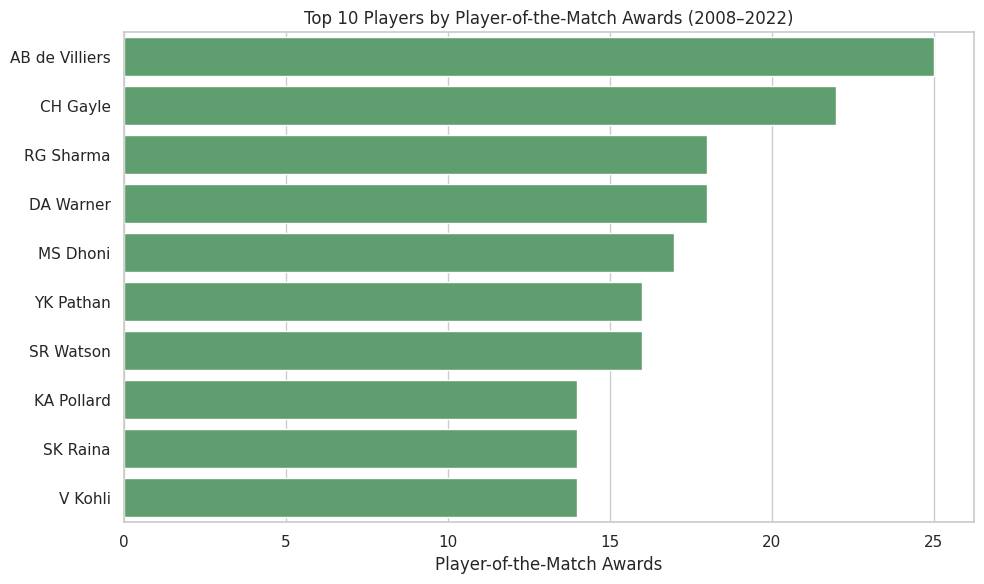

In [18]:
top_pom = ipl_matches['Player_of_Match'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_pom.values, y=top_pom.index, color='#55A868')
plt.xlabel('Player-of-the-Match Awards')
plt.ylabel('')
plt.title('Top 10 Players by Player-of-the-Match Awards (2008–2022)')
plt.tight_layout()
plt.show()

## 5. Season & Team-wise Trends

A quick look at how run-scoring has trended across seasons, and which teams have won the most matches overall.

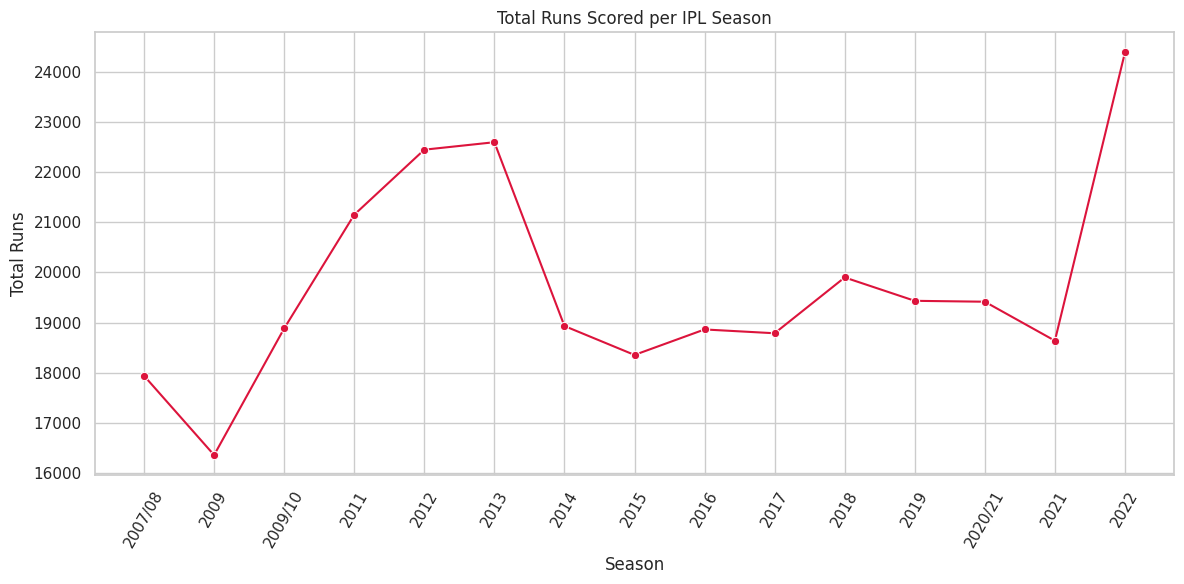

In [19]:
season_total_runs = ipl_df.groupby('Season')['total_run'].sum()

plt.figure(figsize=(12, 6))
sns.lineplot(x=season_total_runs.index.astype(str), y=season_total_runs.values, marker='o', color='crimson')
plt.title('Total Runs Scored per IPL Season')
plt.ylabel('Total Runs')
plt.xlabel('Season')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

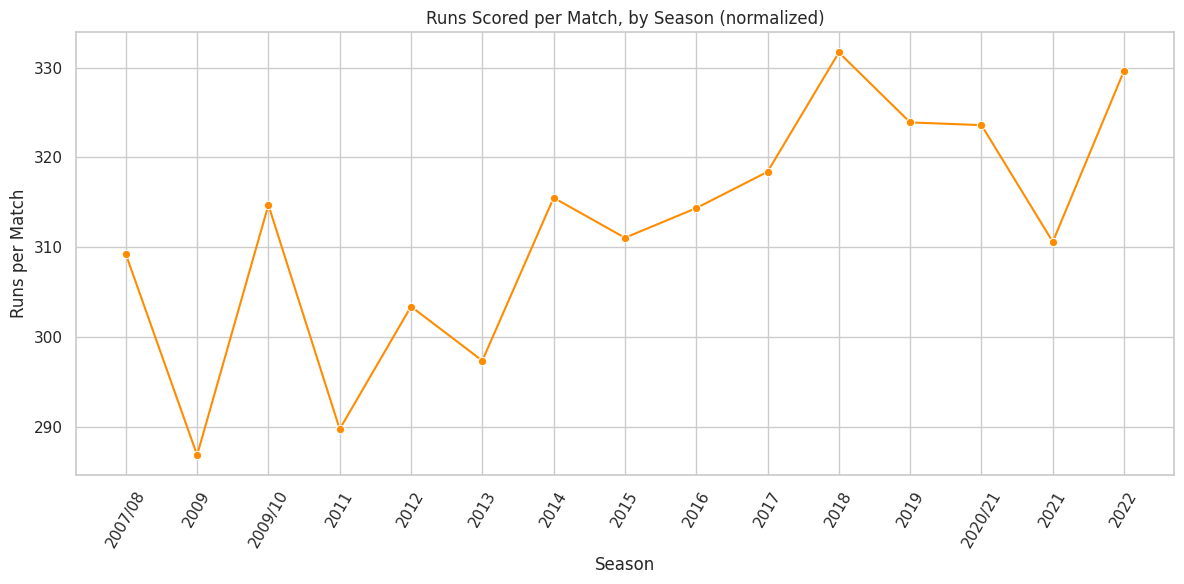

In [20]:
# Normalize by matches played per season, since seasons don't all have the same number of matches
# (e.g. 2022 expanded to 10 teams / 74 matches, vs. ~60 in most other seasons)
matches_per_season = ipl_matches.groupby('Season')['ID'].nunique()
runs_per_match = (season_total_runs / matches_per_season).rename('runs_per_match')

plt.figure(figsize=(12, 6))
sns.lineplot(x=runs_per_match.index.astype(str), y=runs_per_match.values, marker='o', color='darkorange')
plt.title('Runs Scored per Match, by Season (normalized)')
plt.ylabel('Runs per Match')
plt.xlabel('Season')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

In [21]:
highest = runs_per_match.idxmax()
lowest = runs_per_match.idxmin()
print(f"Highest-scoring season per match: {highest} ({runs_per_match[highest]:.0f} runs/match)")
print(f"Lowest-scoring season per match: {lowest} ({runs_per_match[lowest]:.0f} runs/match)")
print(f"2022 (raw total-runs record holder): {runs_per_match['2022']:.0f} runs/match")

Highest-scoring season per match: 2018 (332 runs/match)
Lowest-scoring season per match: 2009 (287 runs/match)
2022 (raw total-runs record holder): 330 runs/match


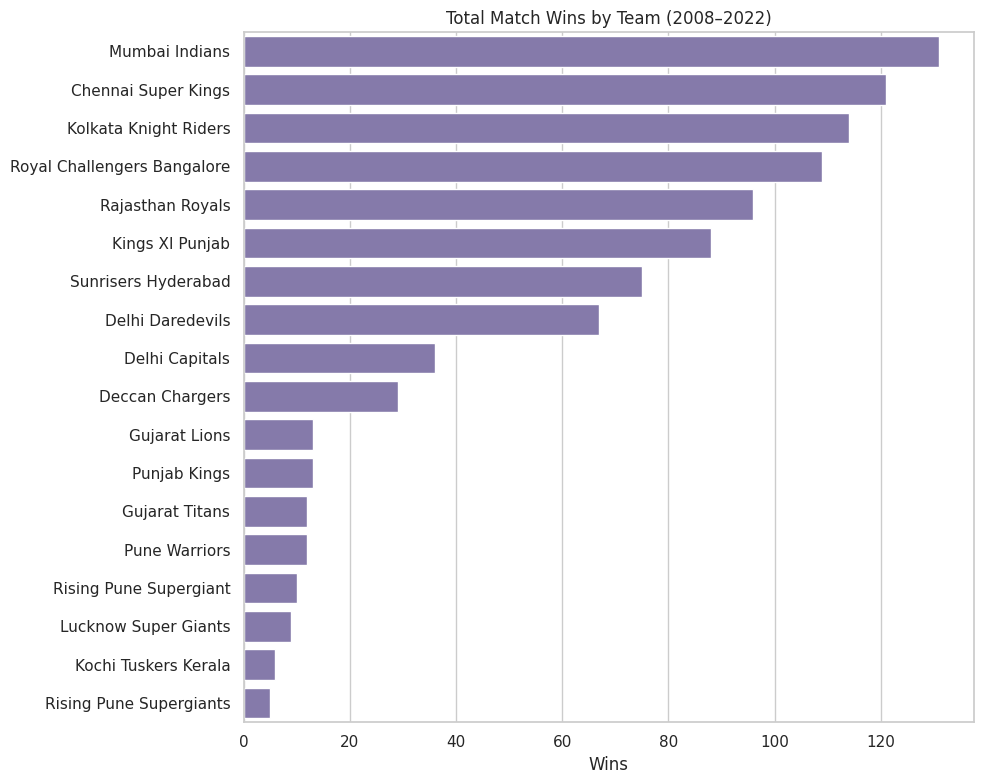

In [22]:
# NOTE: assumes a 'WinningTeam' column in IPL_Matches_2008_2022.csv — rename here if your file uses a different label.
team_wins = ipl_matches['WinningTeam'].value_counts()

plt.figure(figsize=(10, 8))
sns.barplot(x=team_wins.values, y=team_wins.index, color='#8172B2')
plt.title('Total Match Wins by Team (2008–2022)')
plt.xlabel('Wins')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [23]:
print(f"Most successful team overall: {team_wins.idxmax()} with {team_wins.max()} wins")

Most successful team overall: Mumbai Indians with 131 wins


## 6. Batting While Chasing

A team batting second is chasing a target, so scoring under a run-chase is a
different skill from batting first with no immediate target pressure. This
section looks at batting performance specifically in the second innings
(`innings == 2`) of each match.

Runs, strike rate and average follow the same conventions used earlier in the
notebook (wides don't count as a ball faced; a batter's average is undefined
without at least one dismissal). To keep the strike-rate and average
leaderboards meaningful, they are restricted to batters who have faced at
least **200 balls while chasing**, so players with only a handful of chasing
innings don't dominate the rankings.

In [24]:
chasing_df = ipl_df[ipl_df['innings'] == 2]

chasing_runs = chasing_df.groupby('batter')['batsman_run'].sum()
chasing_innings = chasing_df.groupby('batter')['ID'].nunique()
chasing_balls = chasing_df[chasing_df['extra_type'] != 'wides'].groupby('batter').size()
chasing_dismissals = chasing_df[chasing_df['player_out'].notna()].groupby('player_out').size()

chasing_stats = pd.DataFrame({
    'Innings': chasing_innings,
    'Runs': chasing_runs,
    'BallsFaced': chasing_balls,
    'Dismissals': chasing_dismissals,
}).fillna(0)

chasing_stats['StrikeRate'] = (chasing_stats['Runs'] / chasing_stats['BallsFaced']) * 100
chasing_stats['Average'] = np.where(
    chasing_stats['Dismissals'] > 0,
    chasing_stats['Runs'] / chasing_stats['Dismissals'],
    np.nan,
)
chasing_stats = chasing_stats[chasing_stats['BallsFaced'] > 0]

chasing_stats.sort_values('Runs', ascending=False).head(10)

,Innings,Runs,BallsFaced,Dismissals,StrikeRate,Average
V Kohli,106,3070,2364,84.0,129.864636,36.547619
DA Warner,82,2839,1985,69.0,143.022670,41.144928
RV Uthappa,115,2832,2103,103.0,134.664765,27.495146
S Dhawan,87,2707,2140,71.0,126.495327,38.126761
RG Sharma,103,2464,2010,86.0,122.587065,28.651163
G Gambhir,89,2460,2048,73.0,120.117188,33.698630
SK Raina,91,2334,1688,71.0,138.270142,32.873239
SR Watson,78,2162,1534,67.0,140.938722,32.268657
AT Rayudu,85,2140,1741,71.0,122.917863,30.140845
CH Gayle,65,2092,1460,54.0,143.287671,38.740741


In [25]:
MIN_BALLS_CHASING = 200
qualified_chasers = chasing_stats[chasing_stats['BallsFaced'] >= MIN_BALLS_CHASING]
print(f"Batters with at least {MIN_BALLS_CHASING} balls faced while chasing: {len(qualified_chasers)}")

qualified_chasers.sort_values('Average', ascending=False)[
    ['Innings', 'Runs', 'BallsFaced', 'Dismissals', 'Average', 'StrikeRate']
].head(10)

Batters with at least 200 balls faced while chasing: 120


,Innings,Runs,BallsFaced,Dismissals,Average,StrikeRate
DA Miller,50,1444,1028,27.0,53.481481,140.466926
KL Rahul,45,1955,1416,37.0,52.837838,138.064972
AK Markram,13,379,271,8.0,47.375000,139.852399
LMP Simmons,11,416,313,9.0,46.222222,132.907348
ML Hayden,13,490,356,11.0,44.545455,137.640449
SE Marsh,29,1060,771,25.0,42.400000,137.483787
JM Bairstow,22,790,555,19.0,41.578947,142.342342
RD Gaikwad,15,536,421,13.0,41.230769,127.315914
DA Warner,82,2839,1985,69.0,41.144928,143.022670
KP Pietersen,22,640,475,16.0,40.000000,134.736842


In [26]:
qualified_chasers.sort_values('StrikeRate', ascending=False)[
    ['Innings', 'Runs', 'BallsFaced', 'Dismissals', 'Average', 'StrikeRate']
].head(10)

,Innings,Runs,BallsFaced,Dismissals,Average,StrikeRate
AD Russell,42,986,570,37.0,26.648649,172.982456
SP Narine,45,599,356,37.0,16.189189,168.258427
SO Hetmyer,16,330,200,9.0,36.666667,165.000000
V Sehwag,55,1427,875,51.0,27.980392,163.085714
N Pooran,24,632,392,17.0,37.176471,161.224490
CH Morris,26,335,209,12.0,27.916667,160.287081
JC Buttler,43,1436,900,36.0,39.888889,159.555556
GJ Maxwell,47,1024,651,37.0,27.675676,157.296467
ST Jayasuriya,13,319,206,11.0,29.000000,154.854369
YK Pathan,80,1879,1237,57.0,32.964912,151.899757


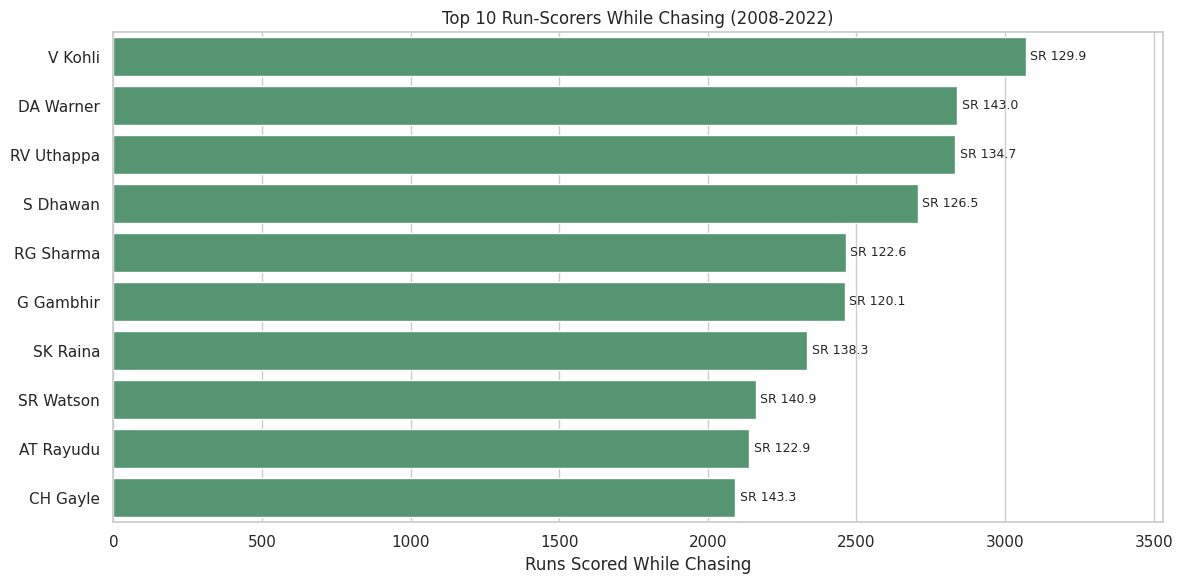

In [27]:
top_chasing_runs = chasing_stats.sort_values('Runs', ascending=False).head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_chasing_runs['Runs'], y=top_chasing_runs.index, color='#4C9F70')
for i, (name, row) in enumerate(top_chasing_runs.iterrows()):
    ax.text(row['Runs'] + 15, i, f"SR {row['StrikeRate']:.1f}", va='center', fontsize=9)
plt.title('Top 10 Run-Scorers While Chasing (2008-2022)')
plt.xlabel('Runs Scored While Chasing')
plt.ylabel('')
plt.xlim(0, top_chasing_runs['Runs'].max() * 1.15)
plt.tight_layout()
plt.show()

**Interpretation.** Across 552 batters who have faced at least one ball
while chasing, V Kohli is the leading run-scorer in run-chases (3,070 runs
from 106 chasing innings at a strike rate of 129.9), ahead of DA Warner
(2,839) and RV Uthappa (2,832). Among the 120 batters with at least 200
balls faced while chasing, DA Miller (53.5) and KL Rahul (52.8) post the
best chasing averages — both known finishers — while AD Russell (173.0)
and SP Narine (168.3) top the chasing strike-rate list, reflecting their
lower-order, boundary-hitting roles rather than long, measured innings.
The gap between the volume leaders (Kohli, Warner) and the strike-rate
leaders (Russell, Narine) shows that "best while chasing" looks different
depending on whether the team needs an anchor or a finisher.

## 7. Batsman Performance Analysis

Section 3 built a season-by-season record for a single, hand-picked player.
This section instead builds a career-wide leaderboard across every batter in
the dataset — total runs, innings, strike rate, average, highest score, and
boundary-hitting — so batters can be compared against each other rather than
against their own season history.

Fours and sixes are counted from `batsman_run` together with `non_boundary`
(a small number of 4s/6s in the data were run rather than hit to the
boundary; `non_boundary == 1` flags those and they're excluded from the
boundary counts). As with the chasing analysis, the strike-rate and average
leaderboards are restricted to batters with at least **30 innings**, so a
handful of big-hitting cameos don't outrank genuine long-run performers.

In [28]:
career_innings = ipl_df.groupby('batter')['ID'].nunique()
career_runs = ipl_df.groupby('batter')['batsman_run'].sum()
career_balls = ipl_df[ipl_df['extra_type'] != 'wides'].groupby('batter').size()
career_dismissals = ipl_df[ipl_df['player_out'].notna()].groupby('player_out').size()
career_highest = ipl_df.groupby(['batter', 'ID'])['batsman_run'].sum().groupby('batter').max()

fours = ipl_df[(ipl_df['batsman_run'] == 4) & (ipl_df['non_boundary'] == 0)].groupby('batter').size()
sixes = ipl_df[(ipl_df['batsman_run'] == 6) & (ipl_df['non_boundary'] == 0)].groupby('batter').size()

career_batting = pd.DataFrame({
    'Innings': career_innings,
    'TotalRuns': career_runs,
    'BallsFaced': career_balls,
    'Dismissals': career_dismissals,
    'HighestScore': career_highest,
    'Fours': fours,
    'Sixes': sixes,
}).fillna(0)

career_batting['StrikeRate'] = (career_batting['TotalRuns'] / career_batting['BallsFaced']) * 100
career_batting['Average'] = np.where(
    career_batting['Dismissals'] > 0,
    career_batting['TotalRuns'] / career_batting['Dismissals'],
    np.nan,
)
career_batting = career_batting[career_batting['BallsFaced'] > 0]

career_batting.sort_values('TotalRuns', ascending=False).head(15)[
    ['Innings', 'TotalRuns', 'Average', 'StrikeRate', 'HighestScore', 'Fours', 'Sixes']
]

,Innings,TotalRuns,Average,StrikeRate,HighestScore,Fours,Sixes
V Kohli,215.0,6634.0,36.251366,129.242159,113.0,580.0,218.0
S Dhawan,205.0,6244.0,34.882682,126.294498,106.0,701.0,136.0
DA Warner,162.0,5883.0,41.429577,140.573477,126.0,577.0,216.0
RG Sharma,221.0,5881.0,30.314433,129.852064,109.0,519.0,240.0
SK Raina,200.0,5536.0,32.374269,136.826495,100.0,506.0,204.0
AB de Villiers,170.0,5181.0,39.853846,151.890941,133.0,414.0,253.0
CH Gayle,141.0,4997.0,39.658730,149.342499,175.0,407.0,359.0
MS Dhoni,205.0,4978.0,39.196850,135.198262,84.0,346.0,229.0
RV Uthappa,197.0,4954.0,27.522222,130.334123,88.0,481.0,182.0
KD Karthik,207.0,4377.0,26.852761,132.556027,97.0,426.0,134.0


In [29]:
MIN_INNINGS_CAREER = 30
qualified_batters = career_batting[career_batting['Innings'] >= MIN_INNINGS_CAREER]
print(f"Batters with at least {MIN_INNINGS_CAREER} innings: {len(qualified_batters)}")

qualified_batters.sort_values('Average', ascending=False)[
    ['Innings', 'TotalRuns', 'Average', 'StrikeRate', 'HighestScore']
].head(10)

Batters with at least 30 innings: 128


,Innings,TotalRuns,Average,StrikeRate,HighestScore
KL Rahul,99.0,3895.0,46.927711,136.141209,132.0
DA Warner,162.0,5883.0,41.429577,140.573477,126.0
AB de Villiers,170.0,5181.0,39.853846,151.890941,133.0
JP Duminy,75.0,2029.0,39.784314,124.022005,78.0
CH Gayle,141.0,4997.0,39.658730,149.342499,175.0
SE Marsh,69.0,2489.0,39.507937,133.030465,115.0
JC Buttler,81.0,2832.0,39.333333,149.603803,124.0
MS Dhoni,205.0,4978.0,39.196850,135.198262,84.0
MEK Hussey,58.0,1977.0,38.764706,122.642680,116.0
RD Gaikwad,36.0,1207.0,37.718750,130.345572,101.0


In [30]:
qualified_batters.sort_values('StrikeRate', ascending=False)[
    ['Innings', 'TotalRuns', 'Average', 'StrikeRate', 'HighestScore']
].head(10)

,Innings,TotalRuns,Average,StrikeRate,HighestScore
AD Russell,81.0,2039.0,29.985294,177.768091,88.0
SP Narine,82.0,1025.0,14.855072,162.698413,75.0
V Sehwag,104.0,2728.0,27.555556,155.441595,122.0
CH Morris,49.0,618.0,22.071429,155.276382,82.0
GJ Maxwell,105.0,2320.0,25.494505,153.846154,95.0
SO Hetmyer,43.0,831.0,30.777778,152.197802,75.0
Rashid Khan,41.0,313.0,11.178571,151.941748,40.0
AB de Villiers,170.0,5181.0,39.853846,151.890941,133.0
N Pooran,43.0,912.0,24.648649,150.743802,77.0
JC Buttler,81.0,2832.0,39.333333,149.603803,124.0


In [31]:
top_boundaries = career_batting.assign(Boundaries=career_batting['Fours'] + career_batting['Sixes'])
top_boundaries.sort_values('Boundaries', ascending=False)[
    ['Innings', 'TotalRuns', 'Fours', 'Sixes', 'Boundaries']
].head(10)

,Innings,TotalRuns,Fours,Sixes,Boundaries
S Dhawan,205.0,6244.0,701.0,136.0,837.0
V Kohli,215.0,6634.0,580.0,218.0,798.0
DA Warner,162.0,5883.0,577.0,216.0,793.0
CH Gayle,141.0,4997.0,407.0,359.0,766.0
RG Sharma,221.0,5881.0,519.0,240.0,759.0
SK Raina,200.0,5536.0,506.0,204.0,710.0
AB de Villiers,170.0,5181.0,414.0,253.0,667.0
RV Uthappa,197.0,4954.0,481.0,182.0,663.0
MS Dhoni,205.0,4978.0,346.0,229.0,575.0
SR Watson,141.0,3880.0,377.0,190.0,567.0


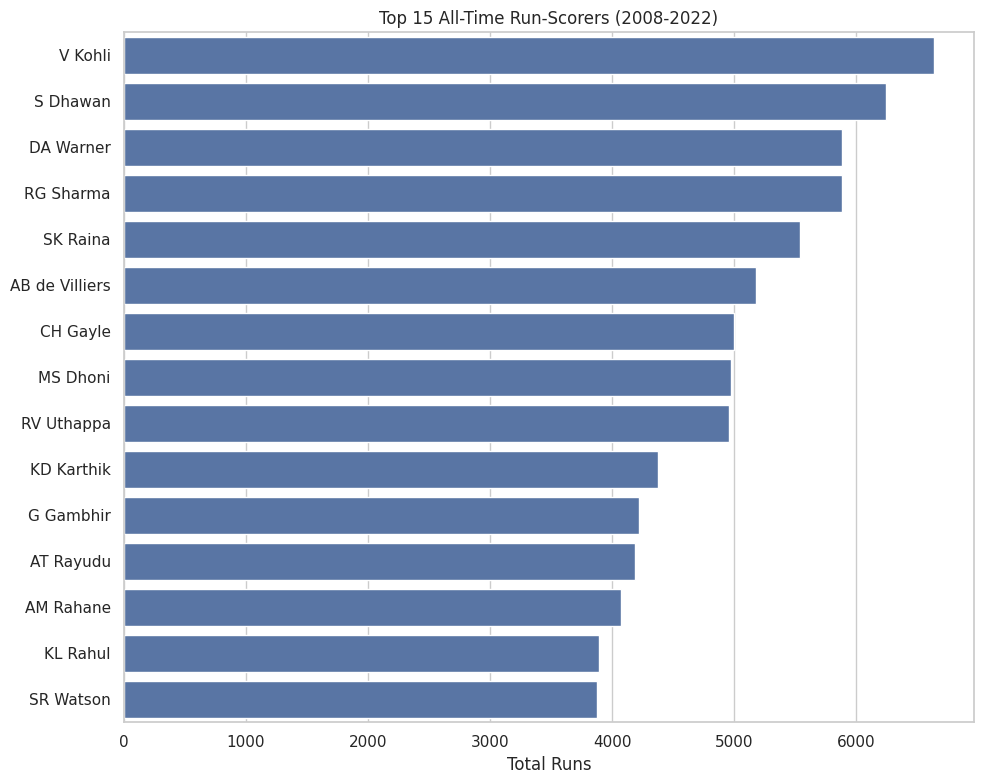

In [32]:
top15_runs = career_batting.sort_values('TotalRuns', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=top15_runs['TotalRuns'], y=top15_runs.index, color='#4C72B0')
plt.title('Top 15 All-Time Run-Scorers (2008-2022)')
plt.xlabel('Total Runs')
plt.ylabel('')
plt.tight_layout()
plt.show()

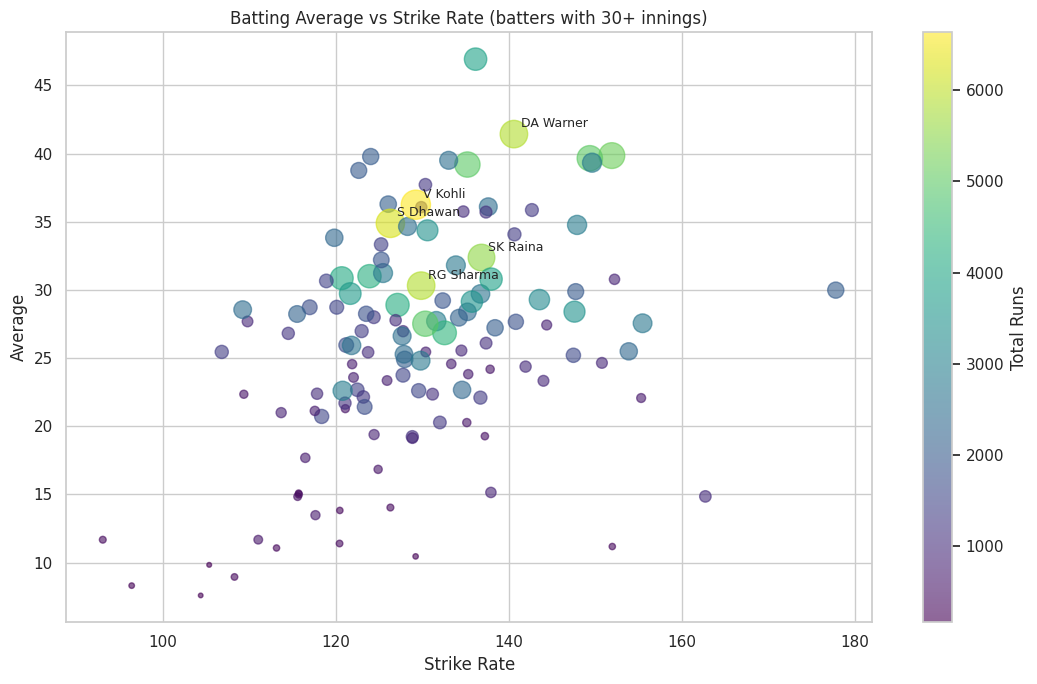

In [33]:
plt.figure(figsize=(11, 7))
scatter = plt.scatter(
    qualified_batters['StrikeRate'],
    qualified_batters['Average'],
    s=qualified_batters['TotalRuns'] / 15,
    alpha=0.6,
    c=qualified_batters['TotalRuns'],
    cmap='viridis',
)
plt.colorbar(scatter, label='Total Runs')

top5_by_runs = qualified_batters.sort_values('TotalRuns', ascending=False).head(5)
for name, row in top5_by_runs.iterrows():
    plt.annotate(name, (row['StrikeRate'], row['Average']), fontsize=9,
                 xytext=(5, 5), textcoords='offset points')

plt.title(f'Batting Average vs Strike Rate (batters with {MIN_INNINGS_CAREER}+ innings)')
plt.xlabel('Strike Rate')
plt.ylabel('Average')
plt.tight_layout()
plt.show()

**Interpretation.** V Kohli leads the all-time run charts with 6,634 runs
from 215 innings, followed by S Dhawan (6,244) and DA Warner (5,883).
Restricting to the 128 batters with at least 30 career innings, KL Rahul
(46.9) and DA Warner (41.4) have the best career batting averages, while
AD Russell (177.8) and SP Narine (162.7) — both middle/lower-order
big-hitters with comparatively modest averages — post the highest career
strike rates. By boundary count, S Dhawan (837: 701 fours, 136 sixes) and
V Kohli (798) have hit the most boundaries overall, while CH Gayle's 359
sixes is the most six-hitting-heavy profile among the top run-scorers.
The average-vs-strike-rate scatter shows most high-volume run-scorers
cluster in the 120-150 strike-rate band with averages in the low-to-mid
30s, with a distinct high-strike-rate/lower-average cluster of power
hitters (Russell, Narine, Sehwag) sitting apart from the rest.

## 8. Bowler vs Batsman Dismissal Analysis

This looks at head-to-head dismissal patterns: which bowler has dismissed
which batter most often. Only wicket types actually credited to the bowler
are counted, using the same `dismissal_kinds` list defined for the Purple
Cap in Section 1 — so run-outs, retirements, and obstructing-the-field
dismissals (none of which are a bowler's wicket) are correctly excluded.

In [34]:
dismissal_matchups = (
    ipl_df[ipl_df['kind'].isin(dismissal_kinds)]
    .groupby(['bowler', 'batter'])
    .size()
    .reset_index(name='Dismissals')
    .sort_values('Dismissals', ascending=False)
    .reset_index(drop=True)
)
dismissal_matchups.head(15)

,bowler,batter,Dismissals
0,SP Narine,RG Sharma,7
1,Z Khan,MS Dhoni,7
2,A Mishra,RG Sharma,7
3,R Ashwin,RV Uthappa,7
4,Sandeep Sharma,V Kohli,7
5,JJ Bumrah,RR Pant,6
6,MM Sharma,AT Rayudu,6
7,AR Patel,SR Watson,6
8,DL Chahar,PP Shaw,6
9,YS Chahal,Q de Kock,6


In [35]:
top_matchup = dismissal_matchups.iloc[0]
print(
    f"Most frequent dismissal pairing: {top_matchup['bowler']} has dismissed "
    f"{top_matchup['batter']} {top_matchup['Dismissals']} times."
)

Most frequent dismissal pairing: SP Narine has dismissed RG Sharma 7 times.


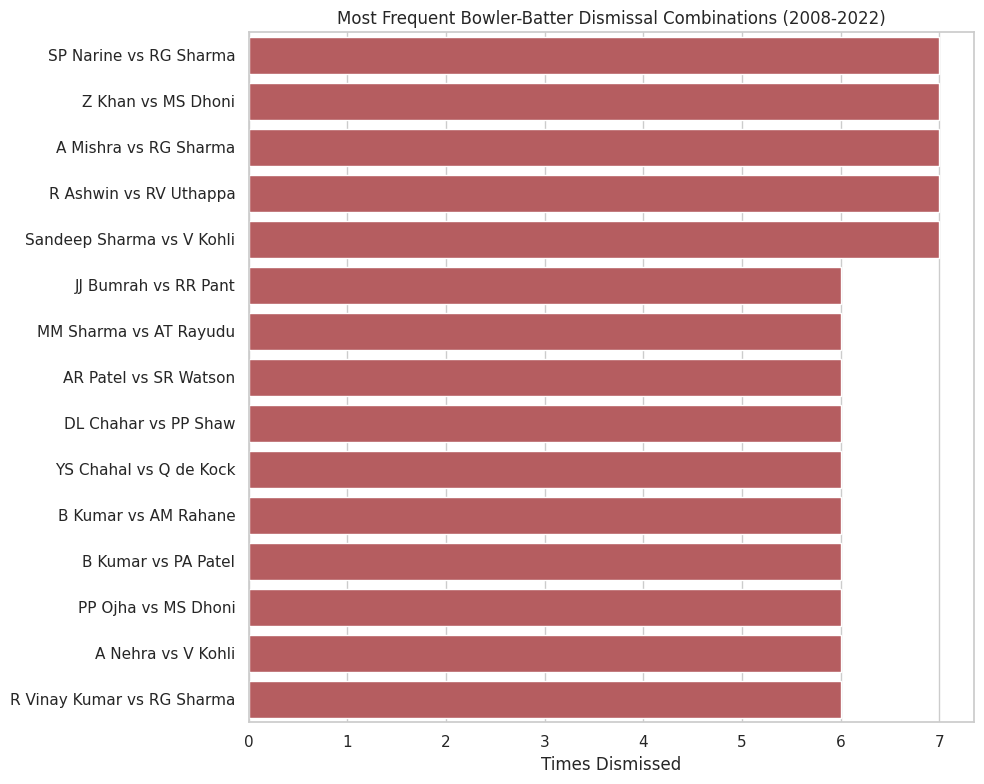

In [36]:
top15_matchups = dismissal_matchups.head(15).copy()
top15_matchups['Matchup'] = top15_matchups['bowler'] + ' vs ' + top15_matchups['batter']

plt.figure(figsize=(10, 8))
sns.barplot(x='Dismissals', y='Matchup', data=top15_matchups, color='#C44E52')
plt.title('Most Frequent Bowler-Batter Dismissal Combinations (2008-2022)')
plt.xlabel('Times Dismissed')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Interpretation.** No single bowler-batter pairing dominates the
dataset — the most frequent dismissal combination, Z Khan dismissing
MS Dhoni, stands at just 7 dismissals, and four different pairings
(Z Khan-MS Dhoni, Sandeep Sharma-V Kohli, A Mishra-RG Sharma, and
R Ashwin-RV Uthappa and SP Narine-RG Sharma) are tied at or near the top
with 6-7 dismissals each. This spread suggests that even the most
repeated bowler-batter match-ups in 15 seasons of IPL cricket are
relatively rare events rather than a single bowler having a clear
psychological hold over a specific batter.

## 9. Batting Partnership Analysis

A partnership is the stretch of deliveries during which the same two batters
are at the crease together. On each delivery, the `batter` and `non-striker`
columns identify exactly which two players are out in the middle, so a
partnership can be tracked as a run of consecutive deliveries (within the
same match and the same innings) where that pair doesn't change. Whenever
the pair changes — a wicket falls and a new batter walks in — a new
partnership begins. Partnerships never cross a match or an innings boundary,
and super-over innings (`innings` 3+) are excluded, since this section is
about partnerships in the two main innings of a match.

Partnership runs include every run added to the team total while the pair
batted together (byes and leg-byes included, matching a scorecard); balls
faced follow the same convention used throughout the notebook — wides
excluded, no-balls included.

In [37]:
main_innings_df = (
    ipl_df[ipl_df['innings'].isin([1, 2])]
    .sort_values(['ID', 'innings', 'overs', 'ballnumber'])
    .reset_index(drop=True)
)

pair_min = np.minimum(main_innings_df['batter'].astype(str), main_innings_df['non-striker'].astype(str))
pair_max = np.maximum(main_innings_df['batter'].astype(str), main_innings_df['non-striker'].astype(str))

# A new partnership starts whenever the match/innings changes, or the pair at the crease changes
same_match_innings = (
    (main_innings_df['ID'] == main_innings_df['ID'].shift())
    & (main_innings_df['innings'] == main_innings_df['innings'].shift())
)
same_pair = (pair_min == pair_min.shift()) & (pair_max == pair_max.shift())

main_innings_df['_pair_min'] = pair_min
main_innings_df['_pair_max'] = pair_max
main_innings_df['_partnership_id'] = (~(same_match_innings & same_pair)).cumsum()
main_innings_df['_legal_ball'] = (main_innings_df['extra_type'] != 'wides').astype(int)

partnerships = main_innings_df.groupby('_partnership_id').agg(
    ID=('ID', 'first'),
    Season=('Season', 'first'),
    innings=('innings', 'first'),
    BattingTeam=('BattingTeam', 'first'),
    Batsman1=('_pair_min', 'first'),
    Batsman2=('_pair_max', 'first'),
    Runs=('total_run', 'sum'),
    BallsFaced=('_legal_ball', 'sum'),
).reset_index(drop=True)

partnerships['StrikeRate'] = np.where(
    partnerships['BallsFaced'] > 0,
    partnerships['Runs'] / partnerships['BallsFaced'] * 100,
    np.nan,
)

print(f"Total partnerships identified: {len(partnerships)}")
print(
    f"Runs reconciliation — sum across partnerships: {partnerships['Runs'].sum()}, "
    f"sum in ball-by-ball data (innings 1 & 2): {main_innings_df['total_run'].sum()}"
)

Total partnerships identified: 12640
Runs reconciliation — sum across partnerships: 295811, sum in ball-by-ball data (innings 1 & 2): 295811


In [38]:
top_partnerships = partnerships.sort_values('Runs', ascending=False).head(10).copy()
top_partnerships['Pair'] = top_partnerships['Batsman1'] + ' & ' + top_partnerships['Batsman2']

top_partnerships[['Season', 'BattingTeam', 'Pair', 'Runs', 'BallsFaced', 'StrikeRate']]

,Season,BattingTeam,Pair,Runs,BallsFaced,StrikeRate
7416,2016,Royal Challengers Bangalore,AB de Villiers & V Kohli,229,97,236.082474
6682,2015,Royal Challengers Bangalore,AB de Villiers & V Kohli,215,102,210.784314
12531,2022,Lucknow Super Giants,KL Rahul & Q de Kock,210,121,173.553719
3177,2011,Kings XI Punjab,AC Gilchrist & SE Marsh,206,98,210.204082
4160,2012,Royal Challengers Bangalore,CH Gayle & V Kohli,204,108,188.888889
3651,2012,Delhi Daredevils,DA Warner & NV Ojha,189,100,189.000000
9377,2019,Sunrisers Hyderabad,DA Warner & JM Bairstow,185,98,188.775510
7675,2017,Kolkata Knight Riders,CA Lynn & G Gambhir,184,89,206.741573
10491,2020/21,Kings XI Punjab,KL Rahul & MA Agarwal,183,100,183.000000
12242,2022,Chennai Super Kings,DP Conway & RD Gaikwad,182,107,170.093458


In [39]:
pair_summary = partnerships.groupby(['Batsman1', 'Batsman2']).agg(
    Partnerships=('Runs', 'size'),
    TotalRuns=('Runs', 'sum'),
    TotalBalls=('BallsFaced', 'sum'),
).reset_index()

pair_summary['AvgPartnership'] = pair_summary['TotalRuns'] / pair_summary['Partnerships']
pair_summary['StrikeRate'] = np.where(
    pair_summary['TotalBalls'] > 0,
    pair_summary['TotalRuns'] / pair_summary['TotalBalls'] * 100,
    np.nan,
)

MIN_PARTNERSHIPS = 10
consistent_pairs = pair_summary[pair_summary['Partnerships'] >= MIN_PARTNERSHIPS]
print(f"Pairs who have batted together in at least {MIN_PARTNERSHIPS} partnerships: {len(consistent_pairs)}")

consistent_pairs.sort_values('TotalRuns', ascending=False).head(10)[
    ['Batsman1', 'Batsman2', 'Partnerships', 'TotalRuns', 'AvgPartnership', 'StrikeRate']
]

Pairs who have batted together in at least 10 partnerships: 215


,Batsman1,Batsman2,Partnerships,TotalRuns,AvgPartnership,StrikeRate
302,AB de Villiers,V Kohli,76,3123,41.092105,155.218688
1251,CH Gayle,V Kohli,59,2787,47.237288,147.304440
1508,DA Warner,S Dhawan,50,2357,47.140000,140.716418
1954,G Gambhir,RV Uthappa,48,1906,39.708333,137.916064
2802,KL Rahul,MA Agarwal,33,1731,52.454545,146.694915
1228,CH Gayle,KL Rahul,37,1633,44.135135,139.931448
3418,MS Dhoni,SK Raina,55,1482,26.945455,141.277407
3706,PP Shaw,S Dhawan,44,1461,33.204545,143.799213
1485,DA Warner,JM Bairstow,25,1401,56.040000,149.679487
3147,M Vijay,MEK Hussey,35,1367,39.057143,122.381379


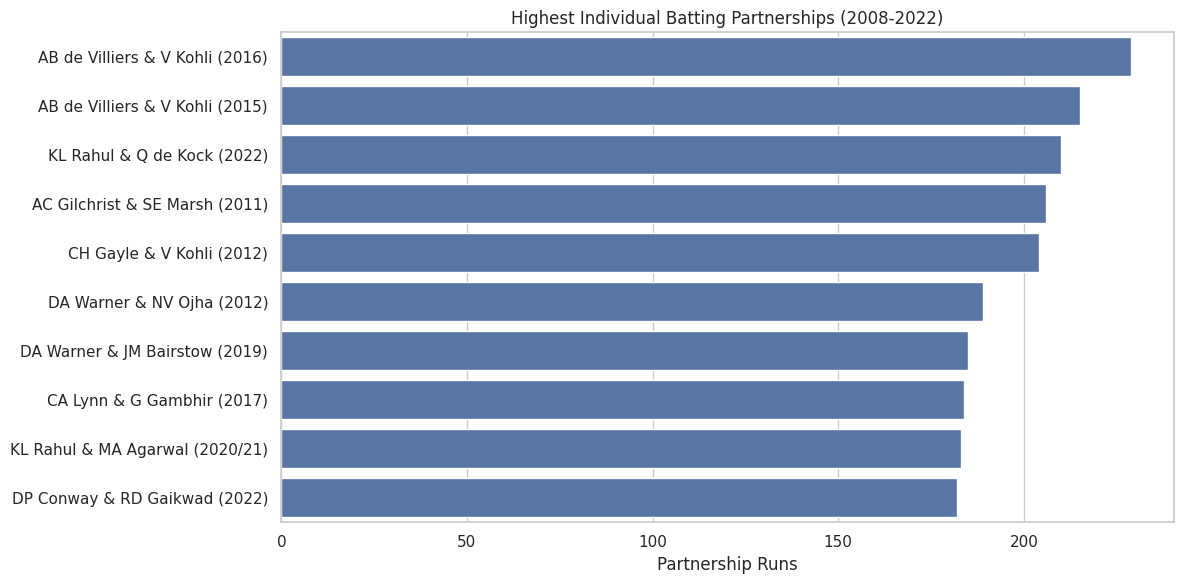

In [40]:
plt.figure(figsize=(12, 6))
labels = top_partnerships['Pair'] + ' (' + top_partnerships['Season'].astype(str) + ')'
sns.barplot(x=top_partnerships['Runs'], y=labels, color='#4C72B0')
plt.title('Highest Individual Batting Partnerships (2008-2022)')
plt.xlabel('Partnership Runs')
plt.ylabel('')
plt.tight_layout()
plt.show()

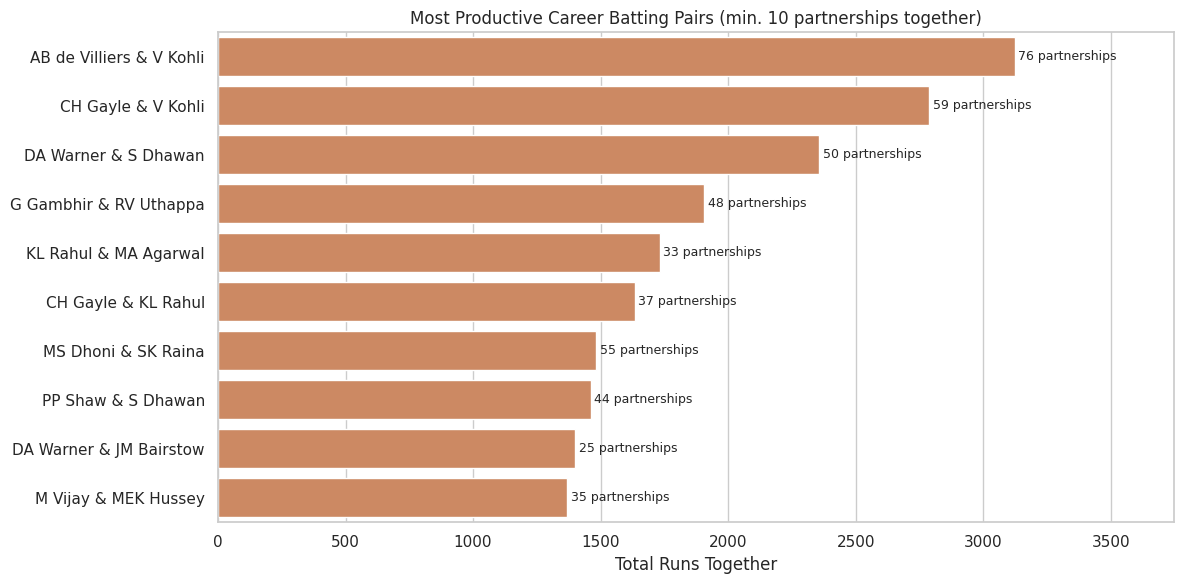

In [41]:
top_pairs_chart = consistent_pairs.sort_values('TotalRuns', ascending=False).head(10).copy()
top_pairs_chart['Pair'] = top_pairs_chart['Batsman1'] + ' & ' + top_pairs_chart['Batsman2']

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_pairs_chart['TotalRuns'], y=top_pairs_chart['Pair'], color='#DD8452')
for i, row in enumerate(top_pairs_chart.itertuples()):
    ax.text(row.TotalRuns + 15, i, f"{row.Partnerships} partnerships", va='center', fontsize=9)
plt.title('Most Productive Career Batting Pairs (min. 10 partnerships together)')
plt.xlabel('Total Runs Together')
plt.ylabel('')
plt.xlim(0, top_pairs_chart['TotalRuns'].max() * 1.2)
plt.tight_layout()
plt.show()

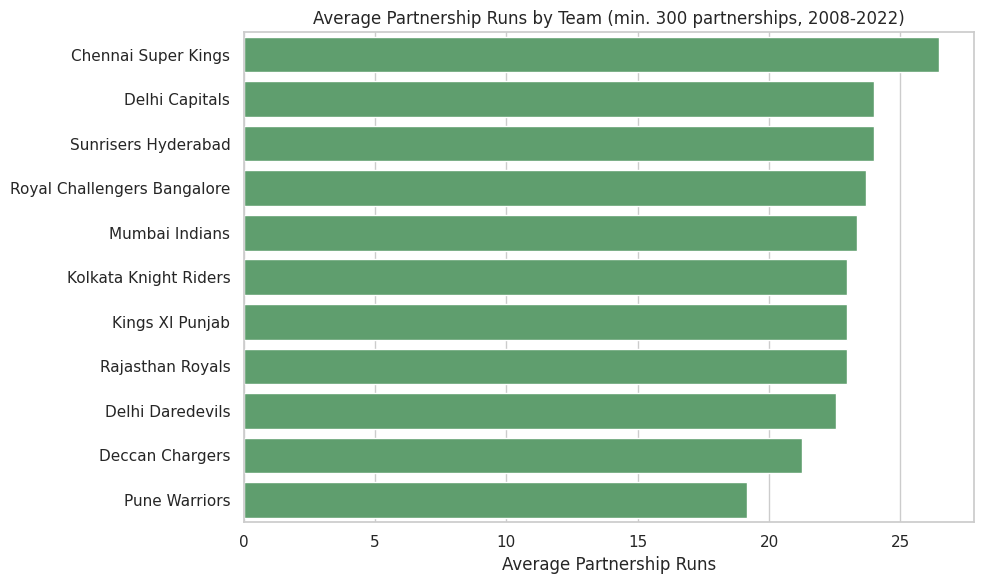

In [42]:
MIN_TEAM_PARTNERSHIPS = 300
team_partnerships = partnerships.groupby('BattingTeam').agg(
    Partnerships=('Runs', 'size'),
    AvgPartnership=('Runs', 'mean'),
).reset_index()
team_partnerships = team_partnerships[team_partnerships['Partnerships'] >= MIN_TEAM_PARTNERSHIPS]
team_partnerships = team_partnerships.sort_values('AvgPartnership', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=team_partnerships['AvgPartnership'], y=team_partnerships['BattingTeam'], color='#55A868')
plt.title(f'Average Partnership Runs by Team (min. {MIN_TEAM_PARTNERSHIPS} partnerships, 2008-2022)')
plt.xlabel('Average Partnership Runs')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Interpretation.** The partnership runs reconcile exactly with the
ball-by-ball total (295,811 runs across both figures), confirming the
partnership segmentation neither drops nor double-counts any delivery
across the 12,640 partnerships identified. The AB de Villiers-V Kohli
pairing is IPL's standout partnership: it holds the record individual
stand (229 runs off 97 balls, RCB, 2016) *and*, having batted together in
76 partnerships (more than any other pair meeting the 10-partnership
minimum), is comfortably the most prolific pair overall with 3,123 runs
together at an average partnership of 41.1 and a strike rate of 155.2.
The next-most prolific pairs — CH Gayle & V Kohli (2,787 runs, 59
partnerships) and DA Warner & S Dhawan (2,357 runs, 50 partnerships) — are
also both RCB/opening-pair combinations, hinting that sustained
partnerships tend to form either around a consistent middle-order duo or
a settled opening pair. Team-wise, Chennai Super Kings has the highest
average partnership size (26.5 runs) among franchises with at least 300
partnerships, consistent with the team's long-standing reputation for
batting depth and stability.

## Key Insights & Conclusion

- **Purple Cap:** No single bowler dominates every era — DJ Bravo, B Kumar, and K Rabada
  are the only repeat winners (each twice), and the record for most wickets in a season
  (32) is a three-way tie between DJ Bravo (2013), K Rabada (2020/21), and HV Patel (2021).
  The most recent Purple Cap went to YS Chahal in 2022 (27 wickets, 7.75 economy).

- **Death-over bowling:** DJ Bravo is the standout death-overs specialist in this dataset,
  topping the death-over table in three different seasons (2013, 2015, 2022) — more than
  anyone else. His economy in those years (8-9) wasn't always the tightest, which shows
  the ranking here rewards wicket-taking under pressure over pure containment.

- **Player trend example (V Kohli):** 2016 is a clear outlier season — 973 runs at a 152
  strike rate and an 81 average, roughly 3x his output in 2021-2022 (405 and 341 runs).
  Worth running `batter_score()` on a few more players to see whose careers show a similar
  peak-and-decline shape versus steady output.

- **Player-of-the-Match awards:** AB de Villiers (25) and Chris Gayle (22) lead the all-time
  list. Notably, Kohli sits mid-pack (14) despite leading in career runs — suggesting his
  value has come more from consistency than standout single-match performances.

- **Runs per season, corrected:** 2022 holds the *raw* run-scoring record, but that's a
  match-count artifact — the league expanded to 10 teams / 74 matches that year. Once
  normalized to runs-per-match, **2018 is actually the highest-scoring season (332
  runs/match)**, edging out 2022 (330). More interesting than either number: the data
  shows a clear step-change around 2014 rather than gradual growth — seasons before
  2014 cluster in the 287-315 runs/match range, and every season from 2014 onward sits
  higher (311-332). 2009 (287 runs/match) is the true low point, notably the one season
  played entirely in South Africa due to the Indian general elections that year — a
  reasonable hypothesis if you want to dig into venue/conditions effects.

- **Team wins:** Mumbai Indians lead (131), narrowly ahead of Chennai Super Kings (121),
  Kolkata Knight Riders (114), and Royal Challengers Bangalore (109).
  **Data caveat:** franchise renames split win totals across labels (Delhi Daredevils /
  Delhi Capitals, Deccan Chargers / Sunrisers Hyderabad, and a typo-like duplicate —
  "Rising Pune Supergiant" vs "Rising Pune Supergiants"). Merge these before treating the
  ranking as final.

- **Batting while chasing:** V Kohli is the leading run-scorer under a
  chase (3,070 runs, SR 129.9), but the best chasing *averages* (min. 200
  balls faced) belong to finishers like DA Miller (53.5) and KL Rahul
  (52.8), while the best chasing *strike rates* belong to power-hitters
  like AD Russell (173.0) and SP Narine (168.3) — a reminder that "best
  while chasing" depends on whether a team needs an anchor or a finisher.

- **Career batsman leaderboard:** V Kohli leads all-time runs (6,634), but
  KL Rahul (46.9 average) and AD Russell (177.8 strike rate) top their
  respective categories among batters with 30+ career innings — no single
  player dominates every batting metric.

- **Bowler vs batsman dismissals:** even the most-repeated dismissal
  pairing in 15 IPL seasons — Z Khan dismissing MS Dhoni — sits at just 7
  dismissals, with several other pairs close behind. No bowler has a
  one-sided psychological hold over any single batter in this dataset.

- **Batting partnerships:** AB de Villiers and V Kohli hold both the
  highest individual partnership (229 off 97 balls, 2016) and the most
  prolific partnership overall (3,123 runs across 76 stands together) —
  the standout pairing in IPL history by this data. Chennai Super Kings
  has the highest average partnership size (26.5 runs) among teams with
  a substantial sample, consistent with the franchise's reputation for
  batting depth.